
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [2]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2



**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_



## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


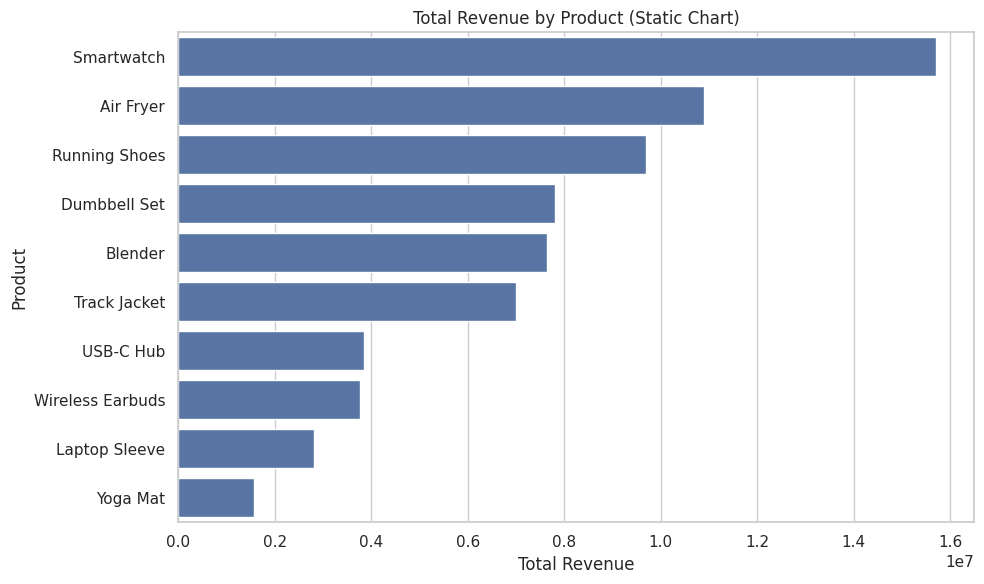

In [3]:
revenue_by_product = sales_df.groupby("product")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x="revenue", y="product", data=revenue_by_product)
plt.title("Total Revenue by Product (Static Chart)")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [4]:
# --- 1b. INTERACTIVE chart ---
# TODO:
#   - Use plotly.express.bar on the SAME grouped data
#   - Add a hover field for "category" (hint: you'll need category alongside revenue -- think about
#     what columns your groupby needs to keep)
#   - Title it clearly

revenue_by_product_interactive = sales_df.groupby(["product", "category"])["revenue"].sum().sort_values(ascending=False).reset_index()

fig_interactive = px.bar(
    revenue_by_product_interactive,
    x="revenue",
    y="product",
    orientation='h',
    title="Total Revenue by Product (Interactive Chart)",
    hover_data={"category": True, "revenue": ':.2f'}
)
fig_interactive.update_layout(yaxis={'categoryorder':'total ascending'})
fig_interactive.show()


**Your 1-2 sentence answer:**

For this specific request, the interactive chart wins because it allows the manager to precisely check the value of each bar without squinting, directly addressing the pain point of needing exact numbers and reducing the need to contact the analytics team.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [5]:
# TODO: create price_slider (FloatRangeSlider) spanning sales_df.unit_price min..max
price_slider = widgets.FloatRangeSlider(
    value=[sales_df['unit_price'].min(), sales_df['unit_price'].max()],
    min=sales_df['unit_price'].min(),
    max=sales_df['unit_price'].max(),
    step=1.0,
    description='Unit Price Range:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# TODO: create units_slider (FloatRangeSlider or IntRangeSlider) spanning sales_df.units_sold min..max
units_slider = widgets.IntRangeSlider(
    value=[int(sales_df['units_sold'].min()), int(sales_df['units_sold'].max())],
    min=int(sales_df['units_sold'].min()),
    max=int(sales_df['units_sold'].max()),
    step=1,
    description='Units Sold Range:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

def dynamic_filter(price_range, units_range):
    # TODO: filter sales_df using both ranges
    filtered_df = sales_df[
        (sales_df['unit_price'] >= price_range[0]) &
        (sales_df['unit_price'] <= price_range[1]) &
        (sales_df['units_sold'] >= units_range[0]) &
        (sales_df['units_sold'] <= units_range[1])
    ]

    # TODO: print "X / Y rows match"
    total_rows = len(sales_df)
    matched_rows = len(filtered_df)
    print(f"{matched_rows} / {total_rows} rows match")

    # TODO: scatter plot: all rows in gray, filtered rows highlighted in color
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot all rows in gray
    ax.scatter(sales_df['unit_price'], sales_df['units_sold'], color='lightgray', alpha=0.5, label='All Data')

    # Plot filtered rows in a distinct color
    ax.scatter(filtered_df['unit_price'], filtered_df['units_sold'], color='blue', alpha=0.7, label='Filtered Data')

    ax.set_title("Unit Price vs. Units Sold (Dynamic Filter)")
    ax.set_xlabel("Unit Price")
    ax.set_ylabel("Units Sold")
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# TODO: call interact(dynamic_filter, price_range=price_slider, units_range=units_slider)
interact(dynamic_filter, price_range=price_slider, units_range=units_slider)


interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Unit Price Range:', max=4999.0, min…

<function __main__.dynamic_filter(price_range, units_range)>


**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_



## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [6]:
store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # TODO 1: bar chart of store_overview, selected store highlighted, others muted gray
    colors = ['blue' if s_id == selected_store else 'lightgray' for s_id in store_overview['store_id']]
    sns.barplot(x="store_id", y="revenue", data=store_overview, palette=colors, ax=axes[0])
    axes[0].set_title(f"Total Revenue by Store (Selected: {selected_store})")
    axes[0].set_xlabel("Store ID")
    axes[0].set_ylabel("Total Revenue")
    axes[0].ticklabel_format(style='plain', axis='y') # Disable scientific notation

    # TODO 2: category breakdown pie/bar for selected_store only
    selected_store_df = sales_df[sales_df['store_id'] == selected_store]
    category_revenue = selected_store_df.groupby('category')['revenue'].sum().reset_index()

    # Using bar chart for consistency with the overall layout
    sns.barplot(x="category", y="revenue", data=category_revenue, ax=axes[1], palette='viridis')
    axes[1].set_title(f"Revenue by Category for {selected_store}")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Revenue")
    axes[1].ticklabel_format(style='plain', axis='y') # Disable scientific notation
    axes[1].tick_params(axis='x', rotation=45)

    # TODO 3: monthly revenue trend line for selected_store only
    monthly_revenue = selected_store_df.groupby('month')['revenue'].sum().reset_index()
    sns.lineplot(x="month", y="revenue", data=monthly_revenue, ax=axes[2], marker='o', color='green')
    axes[2].set_title(f"Monthly Revenue Trend for {selected_store}")
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Revenue")
    axes[2].ticklabel_format(style='plain', axis='y') # Disable scientific notation
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# TODO: wire this up with interact() using a Dropdown of stores["store_id"] values
store_dropdown = widgets.Dropdown(
    options=stores['store_id'].unique().tolist(),
    value=stores['store_id'].unique().tolist()[0],
    description='Select Store:'
)

interact(store_coordinated_view, selected_store=store_dropdown)

interactive(children=(Dropdown(description='Select Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06')…

<function __main__.store_coordinated_view(selected_store)>


**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_



## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [7]:
# --- Part A: find the anomaly ---
# TODO: compute min/median ratio per (store_id, product) and show the 5 most extreme

def min_median_ratio(series):
    if series.median() == 0:
        return 0  # Avoid division by zero, or handle as appropriate for the domain
    return series.min() / series.median()

anomaly_ranking = sales_df.groupby(['store_id', 'product'])['units_sold'].agg(min_median_ratio).sort_values().head(5)

print("Top 5 most extreme drops (min_units_sold / median_units_sold ratio):")
print(anomaly_ranking)

Top 5 most extreme drops (min_units_sold / median_units_sold ratio):
store_id  product     
S03       Smartwatch      0.185714
S05       USB-C Hub       0.250000
S01       Track Jacket    0.300000
S03       USB-C Hub       0.303030
S02       Yoga Mat        0.315789
Name: units_sold, dtype: float64


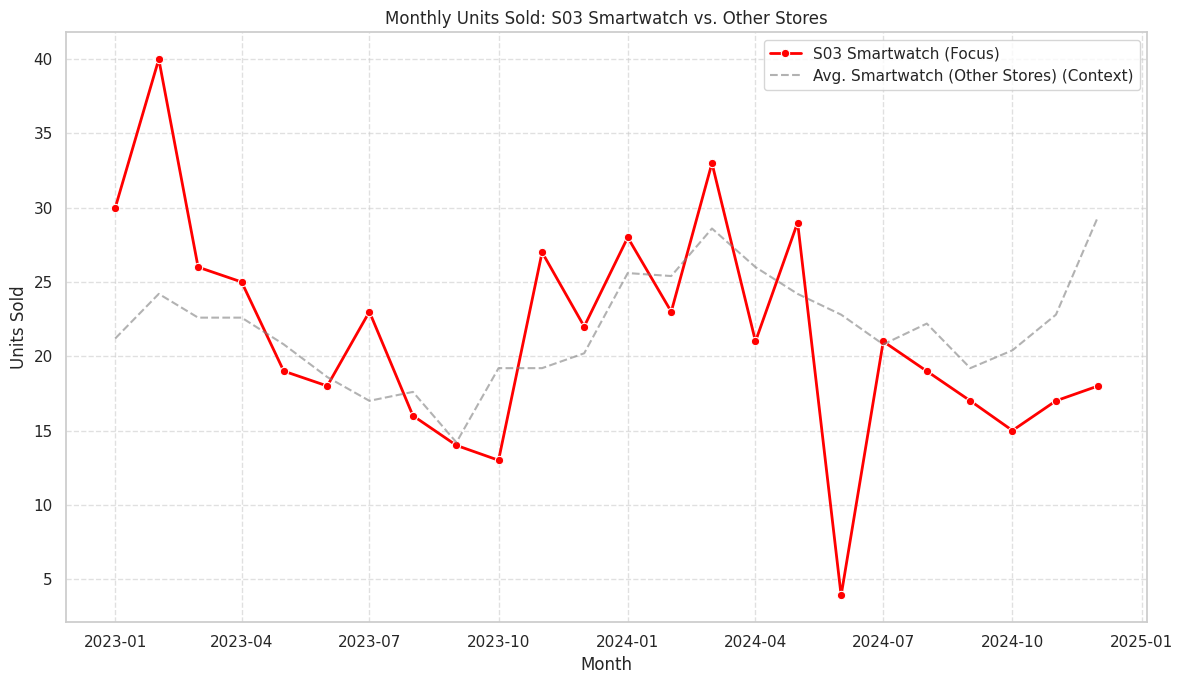

In [9]:

# --- Part B: drill-down with context preserved ---
# TODO 1: build an overview plotly line chart of units_sold over month, one line per (store_id, product)
#         combination, with hover showing store_id + product (cheap-tier epistemic action)

# Prepare data for the overview chart
monthly_product_sales = sales_df.groupby(['month', 'store_id', 'product'])['units_sold'].sum().reset_index()

# Create a combined 'store_product_combination' column for line_group
monthly_product_sales['store_product_combination'] = monthly_product_sales['store_id'] + ' - ' + monthly_product_sales['product']

fig_overview = px.line(
    monthly_product_sales,
    x='month',
    y='units_sold',
    line_group='store_product_combination', # Use the new combined column
    color='store_id',
    hover_name='product', # Show product name on hover
    hover_data={'store_id': True, 'product': True, 'units_sold': ':.0f'},
    title='Monthly Units Sold Trend by Store and Product Overview',
    height=600
)
fig_overview.update_traces(opacity=0.5) # Make lines slightly transparent to prevent clutter
fig_overview.show()

# TODO 2: using the (store_id, product) pair you identified as the top anomaly in Part A,
#         plot its monthly units_sold trend (focus) together with the average trend for that SAME
#         product across all other stores (context), on one shared chart

anomaly_store_id = anomaly_ranking.index[0][0]
anomaly_product = anomaly_ranking.index[0][1]

# Data for the anomalous product (focus)
anomaly_focus_df = sales_df[(sales_df['store_id'] == anomaly_store_id) &
                            (sales_df['product'] == anomaly_product)].groupby('month')['units_sold'].sum().reset_index()

# Data for the average trend of the same product across all other stores (context)
context_product_df = sales_df[(sales_df['product'] == anomaly_product) &
                              (sales_df['store_id'] != anomaly_store_id)].groupby('month')['units_sold'].mean().reset_index()
context_product_df.rename(columns={'units_sold': 'avg_units_sold_other_stores'}, inplace=True)

plt.figure(figsize=(12, 7))
sns.lineplot(x='month', y='units_sold', data=anomaly_focus_df, marker='o', label=f'{anomaly_store_id} {anomaly_product} (Focus)', color='red', linewidth=2)
sns.lineplot(x='month', y='avg_units_sold_other_stores', data=context_product_df, linestyle='--', color='gray', alpha=0.6, label=f'Avg. {anomaly_product} (Other Stores) (Context)')

plt.title(f'Monthly Units Sold: {anomaly_store_id} {anomaly_product} vs. Other Stores')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_



## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [10]:
# TODO: build product_summary with columns: product, revenue (sum), profit (sum), avg_rating (mean)
product_summary = sales_df.groupby('product').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum'),
    avg_rating=('avg_rating', 'mean')
).reset_index()

# TODO: sort descending by revenue
product_summary_revenue_sorted = product_summary.sort_values(by='revenue', ascending=False)

# TODO: style with .style.bar(...) per numeric column + .set_caption(...)
product_summary_revenue_styled = product_summary_revenue_sorted.style.bar(subset=['revenue'], color='#D65F5F') \
                                                    .bar(subset=['profit'], color='#5FBA7D') \
                                                    .bar(subset=['avg_rating'], color='#5F7CD6') \
                                                    .set_caption("Product Performance Summary (Sorted by Revenue)")

display(product_summary_revenue_styled)

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
1,Blender,7648773.000000,1860308.558382,4.039583
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


In [11]:
# TODO: re-sort product_summary by profit descending and re-render the styled table
product_summary_profit_sorted = product_summary.sort_values(by='profit', ascending=False)

product_summary_profit_styled = product_summary_profit_sorted.style.bar(subset=['revenue'], color='#D65F5F') \
                                                    .bar(subset=['profit'], color='#5FBA7D') \
                                                    .bar(subset=['avg_rating'], color='#5F7CD6') \
                                                    .set_caption("Product Performance Summary (Sorted by Profit)")

display(product_summary_profit_styled)

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
1,Blender,7648773.000000,1860308.558382,4.039583
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


Your observation (revenue-sorted vs profit-sorted top rows):

When sorted by revenue, the top products are Smartwatch, Air Fryer, Running Shoes, Dumbbell Set, and Blender. When sorted by profit, Smartwatch, Air Fryer, and Running Shoes remain in the top three positions. However, the order of 'Blender' and 'Dumbbell Set' changes: 'Blender' (which was 5th by revenue) moves to 4th by profit, while 'Dumbbell Set' (which was 4th by revenue) moves to 5th by profit. This indicates that while 'Dumbbell Set' generates higher total revenue than 'Blender', 'Blender' is actually more profitable. This tells a manager that focusing solely on revenue might not reflect true profitability, and a high-revenue product might not necessarily be the most profitable one, highlighting the importance of considering both metrics.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


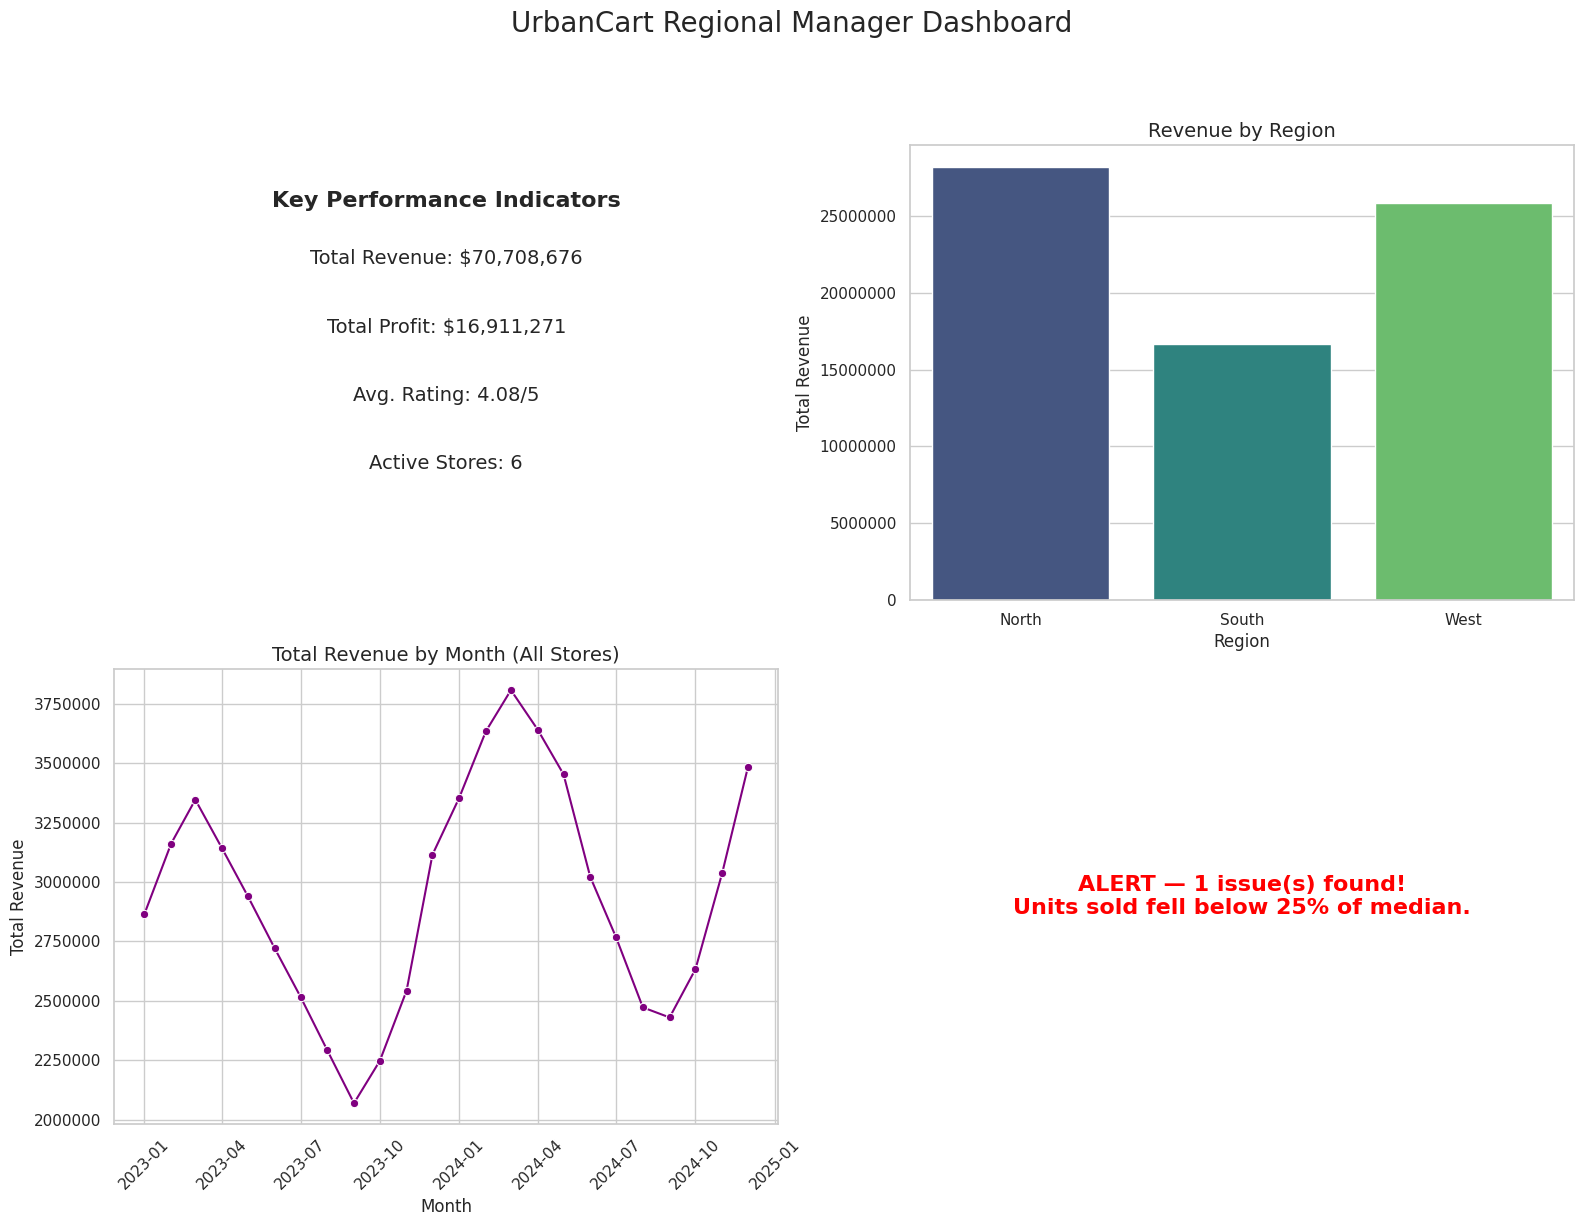

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1: KPI summary (top-left) ---
ax = axes[0, 0]
total_revenue = sales_df['revenue'].sum()
total_profit = sales_df['profit'].sum()
overall_avg_rating = sales_df['avg_rating'].mean()
num_active_stores = sales_df['store_id'].nunique()

ax.axis("off") # Hide axes for text display
ax.text(0.5, 0.9, "Key Performance Indicators", fontsize=16, ha='center', va='top', fontweight='bold')
ax.text(0.5, 0.75, f"Total Revenue: ${total_revenue:,.0f}", fontsize=14, ha='center', va='center')
ax.text(0.5, 0.6, f"Total Profit: ${total_profit:,.0f}", fontsize=14, ha='center', va='center')
ax.text(0.5, 0.45, f"Avg. Rating: {overall_avg_rating:.2f}/5", fontsize=14, ha='center', va='center')
ax.text(0.5, 0.3, f"Active Stores: {num_active_stores}", fontsize=14, ha='center', va='center')

# --- Panel 2: revenue by region (top-right) ---
ax = axes[0, 1]
revenue_by_region = sales_df.groupby('region')['revenue'].sum().reset_index()
sns.barplot(x='region', y='revenue', hue='region', data=revenue_by_region, ax=ax, palette='viridis', legend=False)
ax.set_title('Revenue by Region', fontsize=14)
ax.set_xlabel('Region')
ax.set_ylabel('Total Revenue')
ax.ticklabel_format(style='plain', axis='y') # Disable scientific notation

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
ax = axes[1, 0]
monthly_total_revenue = sales_df.groupby('month')['revenue'].sum().reset_index()
sns.lineplot(x='month', y='revenue', data=monthly_total_revenue, marker='o', ax=ax, color='purple')
ax.set_title('Total Revenue by Month (All Stores)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.ticklabel_format(style='plain', axis='y') # Disable scientific notation
ax.tick_params(axis='x', rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
ax = axes[1, 1]
ax.axis("off") # Hide axes for text display

# Calculate median units_sold for each (store_id, product) pair
sales_df['median_units_sold_per_pair'] = sales_df.groupby(['store_id', 'product'])['units_sold'].transform('median')

# Identify months where units_sold fell below 25% of its own median
anomalous_months = sales_df[sales_df['units_sold'] < (0.25 * sales_df['median_units_sold_per_pair'])]

# Count unique (store_id, product) pairs that have at least one such anomaly
num_issues = anomalous_months[['store_id', 'product']].drop_duplicates().shape[0]

if num_issues > 0:
    alert_message = f"ALERT — {num_issues} issue(s) found!\nUnits sold fell below 25% of median."
    alert_color = 'red'
else:
    alert_message = "OK — No significant drops detected."
    alert_color = 'green'

ax.text(0.5, 0.5, alert_message, fontsize=16, ha='center', va='center', color=alert_color, fontweight='bold')

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=20, y=1.02) # Adjusted suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1.  **Which single technique from this activity do you think gives UrbanCart's managers the *biggest* time saving, and why?**
    The "Coordinated Views & Cross-View Brushing" technique from Task 3 would likely provide the biggest time saving. It directly addresses the complaint of "flipping between many separate PDF pages" by allowing managers to select a store and immediately see its category breakdown and monthly trend alongside the overall store performance, eliminating the need to compile separate reports or dig for data.

2.  **Which technique was hardest to implement well, and what design trade-off (from the lecture) did you have to think about while building it?**
    The "Focus + Context Drill-Down" for anomaly detection in Task 4 was challenging. The primary design trade-off was between "Overview + Detail" and "Focus + Context." The difficulty lay in creating an overview of many trend lines without visual clutter, and then designing the detailed drill-down to clearly show the anomalous trend (focus) while still providing a comparative baseline (context) from other stores, using different interaction tiers effectively (hover for overview, dedicated plot for drill-down).

3.  **If you had to add **one more** interaction technique from the lecture that this activity didn't cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this retail scenario would it actually be useful, and why?**
    A **Magic Lens** could be very useful on the single-screen monitoring dashboard (Task 6). A manager could hover a lens over a specific region in the "Revenue by Region" bar chart, and within that lens, a mini-chart could instantly display the top 3 products or stores for that region. This provides on-demand detail without navigating away or adding permanent clutter, enhancing the dashboard's at-a-glance utility with a low-cost, context-preserving drill-down.